In [92]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Pairs Trading Backtest

This project tests a simple pairs trading strategy using Coca-Cola (KO) and PepsiCo (PEP).

The goal is to examine whether two related stocks can be used in a mean-reversion trading strategy. The strategy is based on the spread between the two stocks, estimated using a hedge ratio, and trading signals generated from the spread's z-score.

The project includes:

- Price data collection
- Price normalization
- Correlation analysis
- Cointegration testing
- Hedge ratio estimation
- Spread and z-score calculation
- Trading signal generation
- Strategy backtesting
- Performance evaluation

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [94]:
pair = ["KO", "PEP"]

start_date = "2015-01-01"
end_date = "2024-12-31"

benchmark = "SPY"

In [95]:
tickers = pair + [benchmark]

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

price_data.head()

Price           Close                              High                               Low                              Open                           Volume                    
Ticker             KO        PEP         SPY         KO        PEP         SPY         KO        PEP         SPY         KO        PEP         SPY        KO      PEP        SPY
Date                                                                                                                                                                            
2015-01-02  29.580019  67.283440  170.124969  29.762527  67.924637  171.325784  29.341357  67.005586  169.089793  29.664252  67.632537  170.911713   9921100  3545700  121465900
2015-01-05  29.580019  66.777618  167.052597  30.162636  67.718048  169.247166  29.537904  66.770492  166.746189  29.966089  67.290575  169.081540  26292600  6441000  169632600
2015-01-06  29.804642  66.271767  165.479172  30.141576  67.411685  167.880776  29.650215  66.214775  164.684151  29.769545  67.026964  167.359043  16897500  6195000  209151400
2015-01-07  30.176672  68.209641  167.541168  30.260905  68.558743  167.880709  29.888874  67.276337  166.356933  30.043300  67.775048  166.804123  13412300  6526300  125346700
2015-01-08  30.541677  69.449287  170.514236  30.583795  69.755640  170.729561  30.253880  68.879328  168.932497  30.310037  68.922073  168.949050  21743600  7131600  147217800

In [52]:
price_data.columns

MultiIndex([( 'Close',  'KO'),
            ( 'Close', 'PEP'),
            ( 'Close', 'SPY'),
            (  'High',  'KO'),
            (  'High', 'PEP'),
            (  'High', 'SPY'),
            (   'Low',  'KO'),
            (   'Low', 'PEP'),
            (   'Low', 'SPY'),
            (  'Open',  'KO'),
            (  'Open', 'PEP'),
            (  'Open', 'SPY'),
            ('Volume',  'KO'),
            ('Volume', 'PEP'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [53]:
prices = price_data["Close"].copy()

prices.head()

Ticker,KO,PEP,SPY
Date,,,
2015-01-02,29.580019,67.283440,170.124969
2015-01-05,29.580019,66.777618,167.052597
2015-01-06,29.804642,66.271767,165.479172
2015-01-07,30.176672,68.209641,167.541168
2015-01-08,30.541677,69.449287,170.514236


In [54]:
prices = prices.ffill().dropna()

print("Price data shape:", prices.shape)
print("Start date:", prices.index.min())
print("End date:", prices.index.max())

prices.head()

Price data shape: (2515, 3)
Start date: 2015-01-02 00:00:00
End date: 2024-12-30 00:00:00


Ticker,KO,PEP,SPY
Date,,,
2015-01-02,29.580019,67.283440,170.124969
2015-01-05,29.580019,66.777618,167.052597
2015-01-06,29.804642,66.271767,165.479172
2015-01-07,30.176672,68.209641,167.541168
2015-01-08,30.541677,69.449287,170.514236


In [56]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.head()

Ticker,KO,PEP,SPY
Date,,,
2015-01-02,1.000000,1.000000,1.000000
2015-01-05,1.000000,0.992482,0.981940
2015-01-06,1.007594,0.984964,0.972692
2015-01-07,1.020171,1.013766,0.984812
2015-01-08,1.032510,1.032190,1.002288


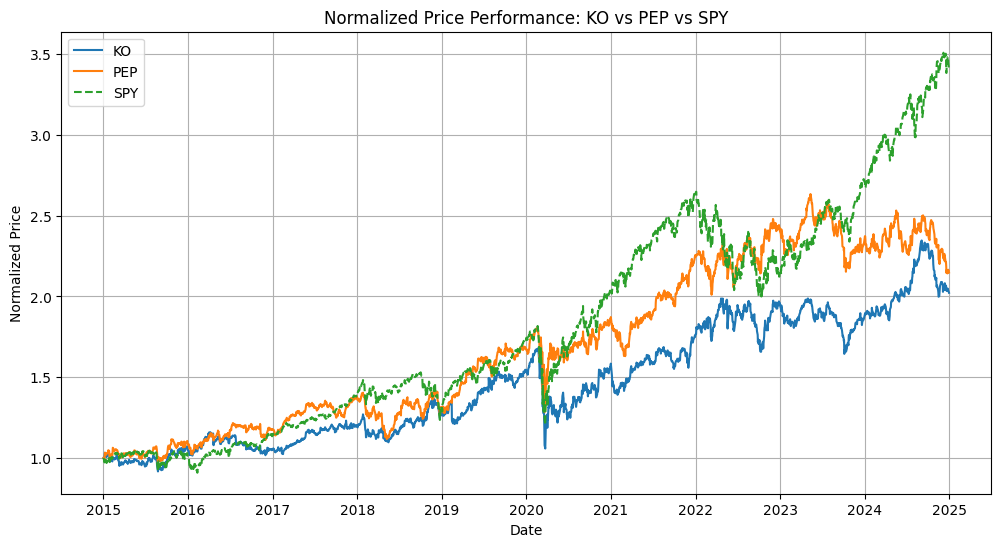

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(normalized_prices.index, normalized_prices["KO"], label="KO")
plt.plot(normalized_prices.index, normalized_prices["PEP"], label="PEP")
plt.plot(normalized_prices.index, normalized_prices["SPY"], label="SPY", linestyle="--")

plt.title("Normalized Price Performance: KO vs PEP vs SPY")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,KO,PEP,SPY
Date,,,
2015-01-05,0.000000,-0.007518,-0.018060
2015-01-06,0.007594,-0.007575,-0.009419
2015-01-07,0.012482,0.029241,0.012461
2015-01-08,0.012096,0.018174,0.017745
2015-01-09,-0.011031,-0.006771,-0.008014


In [59]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,KO,PEP,SPY
Ticker,,,
KO,1.000000,0.740047,0.589721
PEP,0.740047,1.000000,0.594694
SPY,0.589721,0.594694,1.000000


In [60]:
ko_pep_corr = returns["KO"].corr(returns["PEP"])

print("KO-PEP Daily Return Correlation:", round(ko_pep_corr, 4))

KO-PEP Daily Return Correlation: 0.74


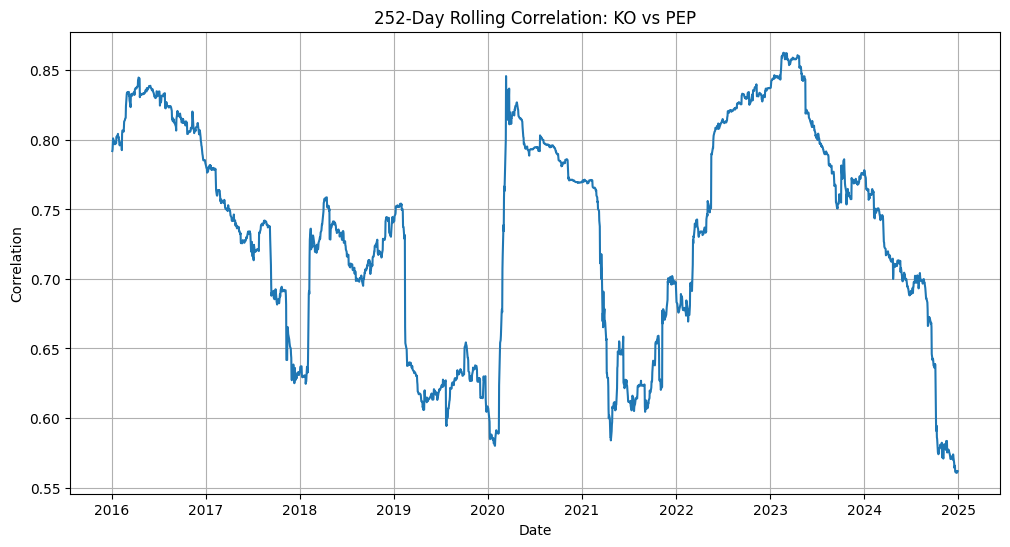

In [61]:
rolling_corr = returns["KO"].rolling(window=252).corr(returns["PEP"])

plt.figure(figsize=(12, 6))

plt.plot(rolling_corr.index, rolling_corr)

plt.title("252-Day Rolling Correlation: KO vs PEP")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

In [62]:
correlation_matrix

Ticker,KO,PEP,SPY
Ticker,,,
KO,1.000000,0.740047,0.589721
PEP,0.740047,1.000000,0.594694
SPY,0.589721,0.594694,1.000000


In [63]:
print("KO-PEP Daily Return Correlation:", round(ko_pep_corr, 4))

KO-PEP Daily Return Correlation: 0.74


In [64]:
score, p_value, critical_values = coint(prices["KO"], prices["PEP"])

print("Cointegration test statistic:", score)
print("P-value:", p_value)
print("Critical values:", critical_values)

Cointegration test statistic: -2.486950889868139
P-value: 0.28485421352517637
Critical values: [-3.90080167 -3.33856151 -3.04613746]


In [65]:
X = sm.add_constant(prices["PEP"])
y = prices["KO"]

model = sm.OLS(y, X).fit()

hedge_ratio = model.params["PEP"]

print("Hedge Ratio:", hedge_ratio)
print(model.summary())

Hedge Ratio: 0.30967491584967144
                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                 4.215e+04
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        14:28:47   Log-Likelihood:                -5898.2
No. Observations:                2515   AIC:                         1.180e+04
Df Residuals:                    2513   BIC:                         1.181e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.88

In [66]:
spread = prices["KO"] - hedge_ratio * prices["PEP"]

spread.head()

Date
2015-01-02    8.744025
2015-01-05    8.900666
2015-01-06    9.281938
2015-01-07    9.053857
2015-01-08    9.034975
dtype: float64

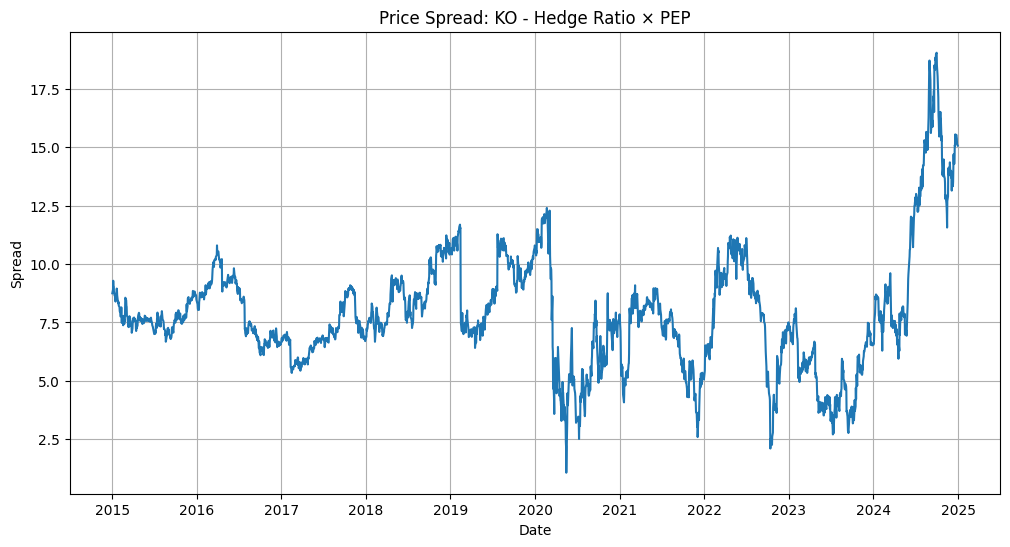

In [67]:
plt.figure(figsize=(12, 6))

plt.plot(spread.index, spread)

plt.title("Price Spread: KO - Hedge Ratio × PEP")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True)
plt.show()

In [68]:
print("Cointegration test statistic:", score)
print("P-value:", p_value)
print("Critical values:", critical_values)

Cointegration test statistic: -2.486950889868139
P-value: 0.28485421352517637
Critical values: [-3.90080167 -3.33856151 -3.04613746]


In [69]:
print("Hedge Ratio:", hedge_ratio)

Hedge Ratio: 0.30967491584967144


In [70]:
candidate_pairs = [
    ("KO", "PEP"),
    ("XOM", "CVX"),
    ("JPM", "BAC"),
    ("V", "MA"),
    ("HD", "LOW"),
    ("MSFT", "AAPL"),
    ("WMT", "TGT"),
    ("COST", "WMT"),
    ("UNH", "CI"),
    ("GS", "MS")
]

In [71]:
candidate_pairs = [
    ("KO", "PEP"),
    ("XOM", "CVX"),
    ("JPM", "BAC"),
    ("V", "MA"),
    ("HD", "LOW"),
    ("MSFT", "AAPL"),
    ("WMT", "TGT"),
    ("COST", "WMT"),
    ("UNH", "CI"),
    ("GS", "MS")
]

unique_tickers = sorted(list(set([ticker for pair in candidate_pairs for ticker in pair])))

pair_price_data = yf.download(
    unique_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

pair_prices = pair_price_data["Close"].copy()
pair_prices = pair_prices.ffill().dropna()

print("Pair price data shape:", pair_prices.shape)
pair_prices.head()

Pair price data shape: (2515, 19)


Ticker,AAPL,BAC,CI,COST,CVX,GS,HD,JPM,KO,LOW,MA,MS,MSFT,PEP,TGT,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,
2015-01-02,24.192602,14.123800,93.412605,113.815186,69.529381,155.555176,79.371269,46.274311,29.580019,54.981071,79.848297,28.405537,39.767689,67.283440,53.871670,83.828766,61.088104,23.127550,57.533413
2015-01-05,23.511055,13.713500,91.804726,112.521156,66.750175,150.698318,77.706032,44.837738,29.580019,53.665455,77.602341,27.517626,39.401989,66.777618,52.906223,82.447990,59.739674,23.060234,55.959194
2015-01-06,23.513277,13.303199,92.168083,114.008095,66.719337,147.649811,77.468124,43.675137,29.804642,53.787266,77.434601,26.725121,38.823681,66.271767,52.899075,82.281616,59.354706,23.237928,55.661697
2015-01-07,23.842981,13.366326,94.330101,115.993248,66.663734,149.850220,80.123322,43.741772,30.176672,55.387131,78.639107,27.106695,39.316948,68.209641,54.901455,83.121742,60.149933,23.854494,56.225719
2015-01-08,24.759083,13.642491,99.135643,116.989883,68.189186,152.242615,81.895958,44.719254,30.541677,56.556606,79.862312,27.510290,40.473564,69.449287,55.158920,87.089447,60.956711,24.357965,57.161545


In [72]:
pair_results = []

for stock_a, stock_b in candidate_pairs:
    temp_prices = pair_prices[[stock_a, stock_b]].dropna()
    temp_returns = temp_prices.pct_change().dropna()
    
    correlation = temp_returns[stock_a].corr(temp_returns[stock_b])
    
    score, p_value, critical_values = coint(
        temp_prices[stock_a],
        temp_prices[stock_b]
    )
    
    X = sm.add_constant(temp_prices[stock_b])
    y = temp_prices[stock_a]
    model = sm.OLS(y, X).fit()
    hedge_ratio = model.params[stock_b]
    
    pair_results.append({
        "Pair": f"{stock_a}-{stock_b}",
        "Stock A": stock_a,
        "Stock B": stock_b,
        "Correlation": correlation,
        "Cointegration P-Value": p_value,
        "Hedge Ratio": hedge_ratio
    })

pair_results_df = pd.DataFrame(pair_results)

pair_results_df = pair_results_df.sort_values("Cointegration P-Value")

pair_results_df

,Pair,Stock A,Stock B,Correlation,Cointegration P-Value,Hedge Ratio
3,V-MA,V,MA,0.893925,0.000048,0.540903
4,HD-LOW,HD,LOW,0.815590,0.123561,1.373869
8,UNH-CI,UNH,CI,0.669633,0.207099,2.117286
0,KO-PEP,KO,PEP,0.740047,0.284854,0.309675
5,MSFT-AAPL,MSFT,AAPL,0.682823,0.308232,1.844482
7,COST-WMT,COST,WMT,0.550120,0.450221,13.393185
9,GS-MS,GS,MS,0.865502,0.524923,3.740012
1,XOM-CVX,XOM,CVX,0.833099,0.693014,0.653671
2,JPM-BAC,JPM,BAC,0.892860,0.976980,4.562712
6,WMT-TGT,WMT,TGT,0.410012,1.000000,0.213619


In [73]:
formatted_pair_results = pair_results_df.copy()

formatted_pair_results["Correlation"] = formatted_pair_results["Correlation"].round(4)
formatted_pair_results["Cointegration P-Value"] = formatted_pair_results["Cointegration P-Value"].round(4)
formatted_pair_results["Hedge Ratio"] = formatted_pair_results["Hedge Ratio"].round(4)

formatted_pair_results

,Pair,Stock A,Stock B,Correlation,Cointegration P-Value,Hedge Ratio
3,V-MA,V,MA,0.8939,0.0000,0.5409
4,HD-LOW,HD,LOW,0.8156,0.1236,1.3739
8,UNH-CI,UNH,CI,0.6696,0.2071,2.1173
0,KO-PEP,KO,PEP,0.7400,0.2849,0.3097
5,MSFT-AAPL,MSFT,AAPL,0.6828,0.3082,1.8445
7,COST-WMT,COST,WMT,0.5501,0.4502,13.3932
9,GS-MS,GS,MS,0.8655,0.5249,3.7400
1,XOM-CVX,XOM,CVX,0.8331,0.6930,0.6537
2,JPM-BAC,JPM,BAC,0.8929,0.9770,4.5627
6,WMT-TGT,WMT,TGT,0.4100,1.0000,0.2136


## Pair Selection

I tested several economically related stock pairs using daily return correlation and cointegration tests.

Among the tested candidates, Visa (V) and Mastercard (MA) showed the strongest statistical relationship:

- Correlation: 0.8939
- Cointegration p-value: 0.0000
- Hedge ratio: 0.5409

Because V and MA are both major payment network companies with similar business models, this pair is also economically meaningful. Therefore, V-MA is selected as the main pair for the pairs trading backtest.

In [74]:
selected_pair = ("V", "MA")

stock_a = selected_pair[0]
stock_b = selected_pair[1]

selected_prices = pair_prices[[stock_a, stock_b]].copy()

selected_prices.head()

Ticker,V,MA
Date,,
2015-01-02,61.088104,79.848297
2015-01-05,59.739674,77.602341
2015-01-06,59.354706,77.434601
2015-01-07,60.149933,78.639107
2015-01-08,60.956711,79.862312


In [75]:
X = sm.add_constant(selected_prices[stock_b])
y = selected_prices[stock_a]

model = sm.OLS(y, X).fit()

hedge_ratio = model.params[stock_b]

print("Selected Pair:", selected_pair)
print("Hedge Ratio:", hedge_ratio)

Selected Pair: ('V', 'MA')
Hedge Ratio: 0.5409033409845309


In [76]:
spread = selected_prices[stock_a] - hedge_ratio * selected_prices[stock_b]

spread_df = pd.DataFrame({
    stock_a: selected_prices[stock_a],
    stock_b: selected_prices[stock_b],
    "Spread": spread
})

spread_df.head()

,V,MA,Spread
Date,,,
2015-01-02,61.088104,79.848297,17.897894
2015-01-05,59.739674,77.602341,17.764308
2015-01-06,59.354706,77.434601,17.470072
2015-01-07,60.149933,78.639107,17.613777
2015-01-08,60.956711,79.862312,17.758919


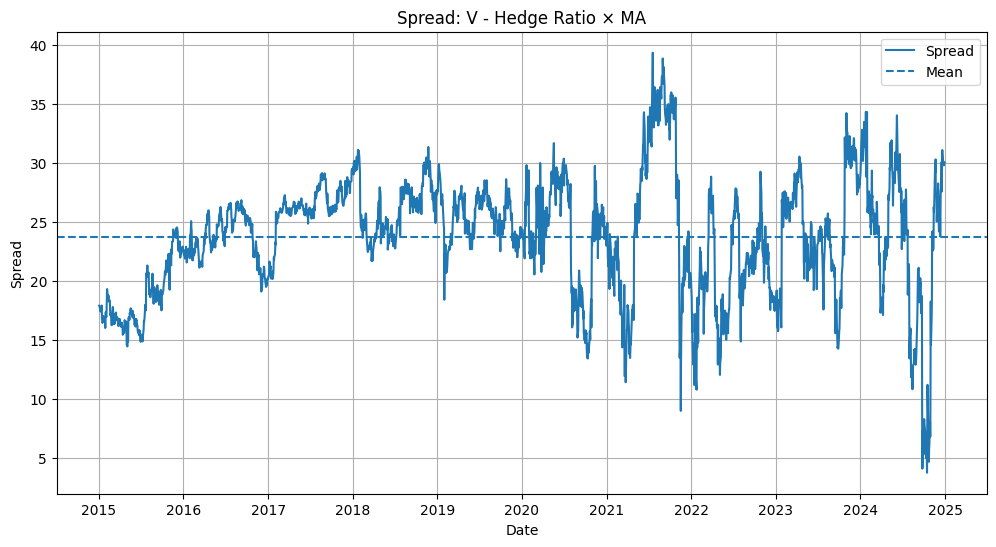

In [77]:
plt.figure(figsize=(12, 6))

plt.plot(spread.index, spread, label="Spread")

plt.axhline(spread.mean(), linestyle="--", label="Mean")

plt.title("Spread: V - Hedge Ratio × MA")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
spread_mean = spread.rolling(window=60).mean()
spread_std = spread.rolling(window=60).std()

z_score = (spread - spread_mean) / spread_std

z_score = z_score.dropna()

z_score.head()

Date
2015-03-30   -1.113709
2015-03-31   -0.550547
2015-04-01   -1.025076
2015-04-02   -1.050344
2015-04-06   -1.311440
dtype: float64

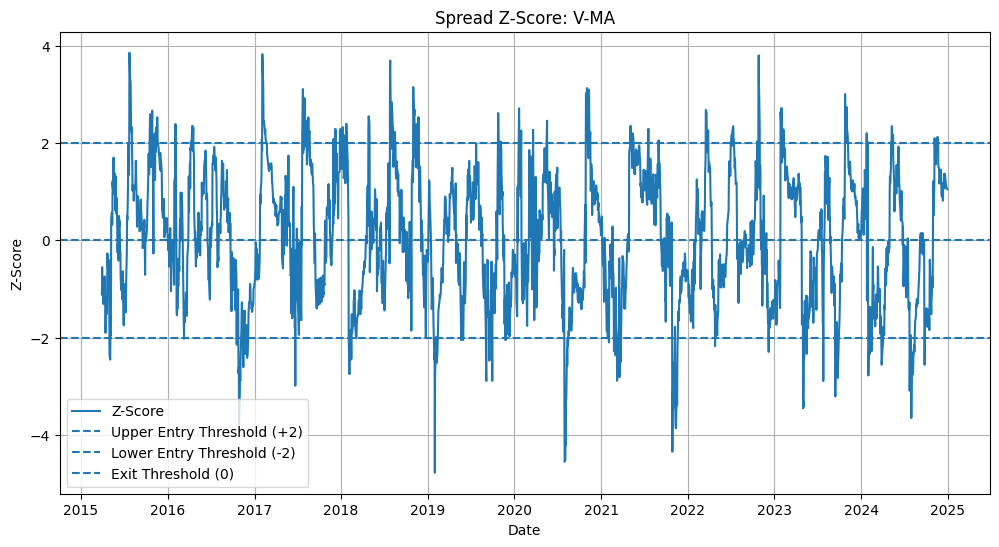

In [79]:
plt.figure(figsize=(12, 6))

plt.plot(z_score.index, z_score, label="Z-Score")

plt.axhline(2.0, linestyle="--", label="Upper Entry Threshold (+2)")
plt.axhline(-2.0, linestyle="--", label="Lower Entry Threshold (-2)")
plt.axhline(0.0, linestyle="--", label="Exit Threshold (0)")

plt.title("Spread Z-Score: V-MA")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
signals = pd.DataFrame(index=z_score.index)

signals["Z-Score"] = z_score
signals["Position"] = 0

position = 0

for i in range(len(signals)):
    z = signals["Z-Score"].iloc[i]
    
    # No position
    if position == 0:
        if z > 2:
            position = -1   # Short spread: short V, long MA
        elif z < -2:
            position = 1    # Long spread: long V, short MA
    
    # Long spread position
    elif position == 1:
        if z >= 0:
            position = 0
    
    # Short spread position
    elif position == -1:
        if z <= 0:
            position = 0
    
    signals.iloc[i, signals.columns.get_loc("Position")] = position

signals.head()

,Z-Score,Position
Date,,
2015-03-30,-1.113709,0
2015-03-31,-0.550547,0
2015-04-01,-1.025076,0
2015-04-02,-1.050344,0
2015-04-06,-1.311440,0


In [81]:
signals["Position"].value_counts()

Position
 0    1059
-1     717
 1     680
Name: count, dtype: int64

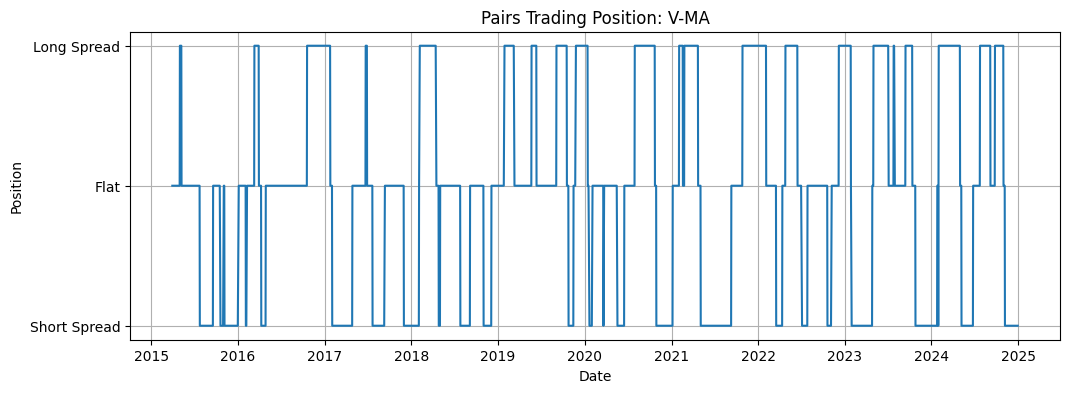

In [82]:
plt.figure(figsize=(12, 4))

plt.plot(signals.index, signals["Position"])

plt.title("Pairs Trading Position: V-MA")
plt.xlabel("Date")
plt.ylabel("Position")
plt.yticks([-1, 0, 1], ["Short Spread", "Flat", "Long Spread"])
plt.grid(True)
plt.show()

In [83]:
selected_returns = selected_prices.pct_change().dropna()
selected_returns = selected_returns.loc[signals.index]

selected_returns.head()

Ticker,V,MA
Date,,
2015-03-30,0.001831,0.004814
2015-03-31,-0.003808,-0.014601
2015-04-01,-0.003516,0.004052
2015-04-02,0.001688,0.003343
2015-04-06,-0.001379,0.003562


In [84]:
signals["Position_Lagged"] = signals["Position"].shift(1)

strategy_returns = (
    signals["Position_Lagged"] *
    (selected_returns[stock_a] - hedge_ratio * selected_returns[stock_b])
)

strategy_returns = strategy_returns.dropna()

strategy_returns.head()

Date
2015-03-31    0.0
2015-04-01   -0.0
2015-04-02   -0.0
2015-04-06   -0.0
2015-04-07    0.0
dtype: float64

In [85]:
benchmark_returns = prices["SPY"].pct_change().dropna()
benchmark_returns = benchmark_returns.loc[strategy_returns.index]

print("Strategy returns shape:", strategy_returns.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

Strategy returns shape: (2455,)
Benchmark returns shape: (2455,)


In [86]:
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_benchmark = (1 + benchmark_returns).cumprod()

pairs_cumulative_returns = pd.DataFrame({
    "Pairs Trading Strategy": cumulative_strategy,
    "SPY Benchmark": cumulative_benchmark
})

pairs_cumulative_returns.tail()

,Pairs Trading Strategy,SPY Benchmark
Date,,
2024-12-23,1.770915,3.383860
2024-12-24,1.763990,3.421472
2024-12-26,1.763343,3.421700
2024-12-27,1.768680,3.385681
2024-12-30,1.775319,3.347045


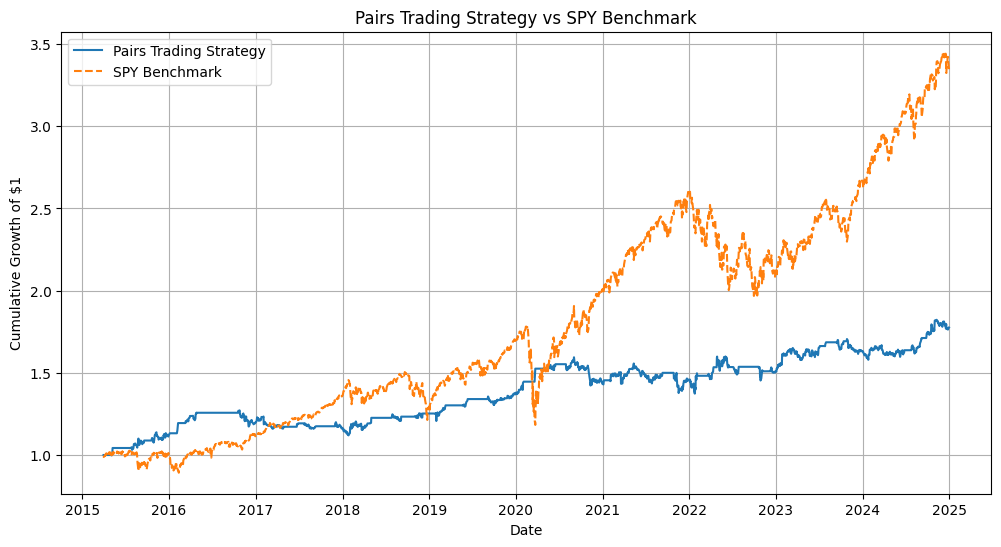

In [87]:
plt.figure(figsize=(12, 6))

plt.plot(
    pairs_cumulative_returns.index,
    pairs_cumulative_returns["Pairs Trading Strategy"],
    label="Pairs Trading Strategy"
)

plt.plot(
    pairs_cumulative_returns.index,
    pairs_cumulative_returns["SPY Benchmark"],
    label="SPY Benchmark",
    linestyle="--"
)

plt.title("Pairs Trading Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
def calculate_performance_metrics(returns, risk_free_rate=0.0):
    total_return = (1 + returns).prod() - 1
    
    trading_days = 252
    annualized_return = (1 + total_return) ** (trading_days / len(returns)) - 1
    
    annualized_volatility = returns.std() * np.sqrt(trading_days)
    
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative / running_max) - 1
    max_drawdown = drawdown.min()
    
    win_rate = (returns > 0).mean()
    
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate
    }

In [89]:
pairs_strategy_metrics = calculate_performance_metrics(strategy_returns)
pairs_benchmark_metrics = calculate_performance_metrics(benchmark_returns)

pairs_metrics_df = pd.DataFrame({
    "Pairs Trading Strategy": pairs_strategy_metrics,
    "SPY Benchmark": pairs_benchmark_metrics
})

pairs_metrics_df

,Pairs Trading Strategy,SPY Benchmark
Total Return,0.775319,2.347045
Annualized Return,0.060688,0.132023
Annualized Volatility,0.092758,0.177009
Sharpe Ratio,0.654263,0.745857
Max Drawdown,-0.138766,-0.337173
Win Rate,0.292057,0.547862


In [90]:
percentage_rows = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Win Rate"
]

pairs_formatted_metrics = pairs_metrics_df.copy().astype(object)

for row in percentage_rows:
    pairs_formatted_metrics.loc[row] = pairs_formatted_metrics.loc[row].apply(lambda x: f"{x:.2%}")

pairs_formatted_metrics.loc["Sharpe Ratio"] = pairs_formatted_metrics.loc["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

pairs_formatted_metrics

,Pairs Trading Strategy,SPY Benchmark
Total Return,77.53%,234.70%
Annualized Return,6.07%,13.20%
Annualized Volatility,9.28%,17.70%
Sharpe Ratio,0.65,0.75
Max Drawdown,-13.88%,-33.72%
Win Rate,29.21%,54.79%


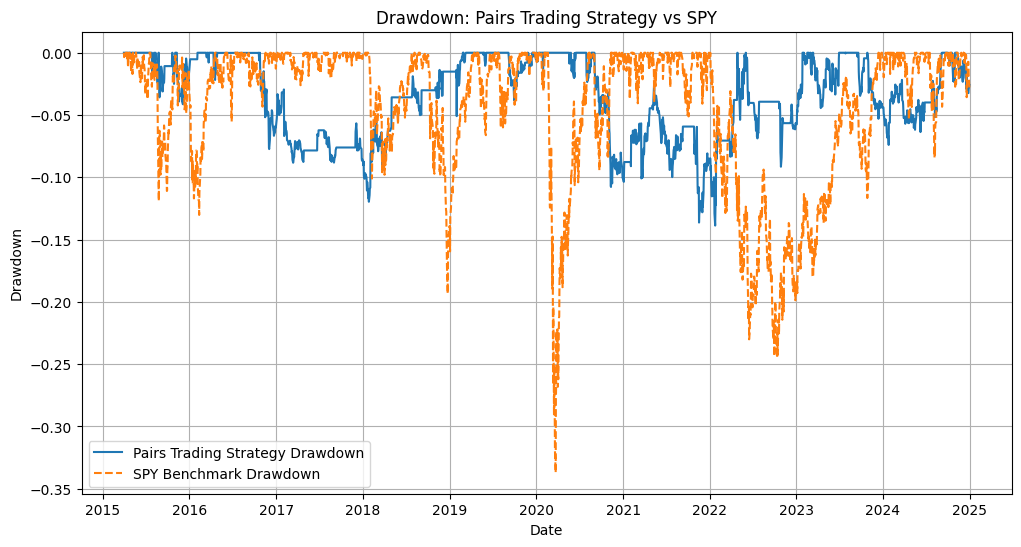

In [91]:
pairs_strategy_cumulative = (1 + strategy_returns).cumprod()
pairs_benchmark_cumulative = (1 + benchmark_returns).cumprod()

pairs_strategy_drawdown = (pairs_strategy_cumulative / pairs_strategy_cumulative.cummax()) - 1
pairs_benchmark_drawdown = (pairs_benchmark_cumulative / pairs_benchmark_cumulative.cummax()) - 1

plt.figure(figsize=(12, 6))

plt.plot(pairs_strategy_drawdown.index, pairs_strategy_drawdown, label="Pairs Trading Strategy Drawdown")
plt.plot(pairs_benchmark_drawdown.index, pairs_benchmark_drawdown, label="SPY Benchmark Drawdown", linestyle="--")

plt.title("Drawdown: Pairs Trading Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
position_changes = signals["Position"].diff().fillna(0)

num_position_changes = (position_changes != 0).sum()
num_entries = ((signals["Position"].shift(1) == 0) & (signals["Position"] != 0)).sum()
num_exits = ((signals["Position"].shift(1) != 0) & (signals["Position"] == 0)).sum()

print("Number of position changes:", num_position_changes)
print("Number of entries:", num_entries)
print("Number of exits:", num_exits)

Number of position changes: 91
Number of entries: 46
Number of exits: 46


## Initial Backtest Results

The V-MA pairs trading strategy generated positive returns over the 2015–2024 period.

The strategy achieved a total return of 77.53% and an annualized return of 6.07%. This was lower than SPY, which returned 234.70% over the same period.

However, the pairs trading strategy showed a much lower risk profile:

- Annualized Volatility: 9.28% vs 17.70% for SPY
- Maximum Drawdown: -13.88% vs -33.72% for SPY

The Sharpe ratio of the strategy was 0.65, compared with 0.75 for SPY. This means that although the strategy reduced risk significantly, it did not outperform SPY on a risk-adjusted basis.

The strategy generated 46 entries and 46 exits during the backtest period, suggesting a moderate trading frequency.

Overall, the V-MA pairs trading strategy produced positive and relatively stable returns, but did not outperform SPY in total return or Sharpe ratio.

In [99]:
transaction_cost = 0.001  # 0.10%

strategy_returns_tc = strategy_returns.copy()

position_changes_aligned = signals["Position"].diff().abs()
position_changes_aligned = position_changes_aligned.loc[strategy_returns_tc.index]

strategy_returns_tc = strategy_returns_tc - (position_changes_aligned * transaction_cost)

strategy_returns_tc = strategy_returns_tc.dropna()

strategy_returns_tc.head()

Date
2015-03-31    0.0
2015-04-01   -0.0
2015-04-02   -0.0
2015-04-06   -0.0
2015-04-07    0.0
dtype: float64

In [100]:
pairs_strategy_metrics_tc = calculate_performance_metrics(strategy_returns_tc)

pairs_metrics_tc_df = pd.DataFrame({
    "Pairs Trading Strategy": pairs_strategy_metrics,
    "Pairs Trading Strategy with TC": pairs_strategy_metrics_tc,
    "SPY Benchmark": pairs_benchmark_metrics
})

pairs_formatted_metrics_tc = pairs_metrics_tc_df.copy().astype(object)

for row in percentage_rows:
    pairs_formatted_metrics_tc.loc[row] = pairs_formatted_metrics_tc.loc[row].apply(lambda x: f"{x:.2%}")

pairs_formatted_metrics_tc.loc["Sharpe Ratio"] = pairs_formatted_metrics_tc.loc["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

pairs_formatted_metrics_tc

,Pairs Trading Strategy,Pairs Trading Strategy with TC,SPY Benchmark
Total Return,77.53%,62.17%,234.70%
Annualized Return,6.07%,5.09%,13.20%
Annualized Volatility,9.28%,9.22%,17.70%
Sharpe Ratio,0.65,0.55,0.75
Max Drawdown,-13.88%,-14.73%,-33.72%
Win Rate,29.21%,29.21%,54.79%


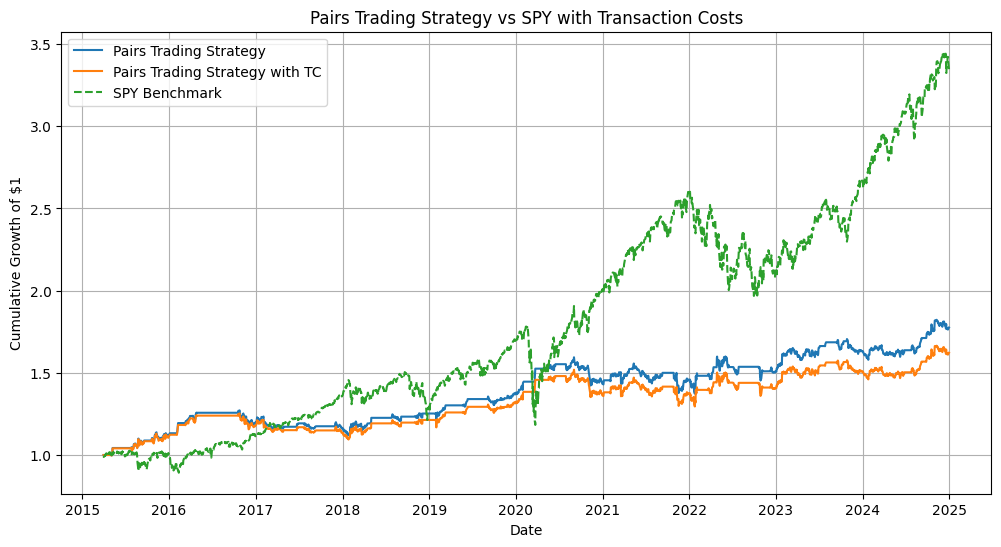

In [101]:
cumulative_strategy_tc = (1 + strategy_returns_tc).cumprod()

pairs_cumulative_returns_tc = pd.DataFrame({
    "Pairs Trading Strategy": cumulative_strategy,
    "Pairs Trading Strategy with TC": cumulative_strategy_tc,
    "SPY Benchmark": cumulative_benchmark
})

plt.figure(figsize=(12, 6))

plt.plot(
    pairs_cumulative_returns_tc.index,
    pairs_cumulative_returns_tc["Pairs Trading Strategy"],
    label="Pairs Trading Strategy"
)

plt.plot(
    pairs_cumulative_returns_tc.index,
    pairs_cumulative_returns_tc["Pairs Trading Strategy with TC"],
    label="Pairs Trading Strategy with TC"
)

plt.plot(
    pairs_cumulative_returns_tc.index,
    pairs_cumulative_returns_tc["SPY Benchmark"],
    label="SPY Benchmark",
    linestyle="--"
)

plt.title("Pairs Trading Strategy vs SPY with Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## Transaction Cost Analysis

After applying a 0.10% transaction cost for each position change, the strategy's performance declined but remained positive.

The total return decreased from 77.53% to 62.17%, while the Sharpe ratio declined from 0.65 to 0.55. Maximum drawdown slightly worsened from -13.88% to -14.73%.

These results show that transaction costs have a meaningful impact on pairs trading performance. Since pairs trading involves both long and short positions, trading costs are especially important to consider.

Even after transaction costs, the strategy maintained a lower volatility and smaller maximum drawdown than SPY. However, it did not outperform SPY in total return or risk-adjusted performance.

In [103]:
def run_pairs_backtest(
    selected_prices,
    stock_a,
    stock_b,
    hedge_ratio,
    window=60,
    entry_threshold=2.0,
    exit_threshold=0.0,
    transaction_cost=0.001
):
    spread = selected_prices[stock_a] - hedge_ratio * selected_prices[stock_b]
    
    spread_mean = spread.rolling(window=window).mean()
    spread_std = spread.rolling(window=window).std()
    z_score = ((spread - spread_mean) / spread_std).dropna()
    
    signals = pd.DataFrame(index=z_score.index)
    signals["Z-Score"] = z_score
    signals["Position"] = 0
    
    position = 0
    
    for i in range(len(signals)):
        z = signals["Z-Score"].iloc[i]
        
        if position == 0:
            if z > entry_threshold:
                position = -1
            elif z < -entry_threshold:
                position = 1
        
        elif position == 1:
            if z >= exit_threshold:
                position = 0
        
        elif position == -1:
            if z <= -exit_threshold:
                position = 0
        
        signals.iloc[i, signals.columns.get_loc("Position")] = position
    
    selected_returns = selected_prices.pct_change().dropna()
    selected_returns = selected_returns.loc[signals.index]
    
    signals["Position_Lagged"] = signals["Position"].shift(1)
    
    strategy_returns = (
        signals["Position_Lagged"] *
        (selected_returns[stock_a] - hedge_ratio * selected_returns[stock_b])
    )
    
    strategy_returns = strategy_returns.dropna()
    
    position_changes = signals["Position"].diff().abs()
    position_changes = position_changes.loc[strategy_returns.index]
    
    strategy_returns_tc = strategy_returns - (position_changes * transaction_cost)
    strategy_returns_tc = strategy_returns_tc.dropna()
    
    metrics = calculate_performance_metrics(strategy_returns_tc)
    
    num_entries = ((signals["Position"].shift(1) == 0) & (signals["Position"] != 0)).sum()
    num_exits = ((signals["Position"].shift(1) != 0) & (signals["Position"] == 0)).sum()
    
    return {
        "Window": window,
        "Entry Threshold": entry_threshold,
        "Exit Threshold": exit_threshold,
        "Total Return": metrics["Total Return"],
        "Annualized Return": metrics["Annualized Return"],
        "Annualized Volatility": metrics["Annualized Volatility"],
        "Sharpe Ratio": metrics["Sharpe Ratio"],
        "Max Drawdown": metrics["Max Drawdown"],
        "Win Rate": metrics["Win Rate"],
        "Entries": num_entries,
        "Exits": num_exits
    }

In [104]:
windows = [30, 60, 90]
entry_thresholds = [1.5, 2.0, 2.5]

optimization_results = []

for window in windows:
    for entry_threshold in entry_thresholds:
        result = run_pairs_backtest(
            selected_prices=selected_prices,
            stock_a=stock_a,
            stock_b=stock_b,
            hedge_ratio=hedge_ratio,
            window=window,
            entry_threshold=entry_threshold,
            exit_threshold=0.0,
            transaction_cost=0.001
        )
        
        optimization_results.append(result)

optimization_results_df = pd.DataFrame(optimization_results)

optimization_results_df = optimization_results_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

optimization_results_df

,Window,Entry Threshold,Exit Threshold,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Entries,Exits
7,90,2.0,0.0,0.867521,0.067061,0.084441,0.794177,-0.102195,0.239588,35,35
6,90,1.5,0.0,1.081565,0.079161,0.100703,0.786083,-0.117389,0.336907,52,52
8,90,2.5,0.0,0.487138,0.042102,0.068905,0.611022,-0.095728,0.145567,19,20
4,60,2.0,0.0,0.621672,0.050878,0.092238,0.551594,-0.147311,0.292057,46,46
5,60,2.5,0.0,0.410070,0.035903,0.072445,0.495595,-0.126163,0.204481,29,30
3,60,1.5,0.0,0.608132,0.049974,0.106208,0.470529,-0.172716,0.344196,64,64
0,30,1.5,0.0,0.237655,0.021858,0.104568,0.209027,-0.160005,0.327565,108,108
2,30,2.5,0.0,-0.008814,-0.000897,0.076148,-0.011785,-0.163040,0.181489,45,46
1,30,2.0,0.0,-0.047649,-0.004939,0.091137,-0.054189,-0.243586,0.258753,73,74


In [105]:
formatted_optimization_results = optimization_results_df.copy()

percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Win Rate"
]

for col in percentage_columns:
    formatted_optimization_results[col] = formatted_optimization_results[col].apply(lambda x: f"{x:.2%}")

formatted_optimization_results["Sharpe Ratio"] = formatted_optimization_results["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

formatted_optimization_results

,Window,Entry Threshold,Exit Threshold,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Entries,Exits
7,90,2.0,0.0,86.75%,6.71%,8.44%,0.79,-10.22%,23.96%,35,35
6,90,1.5,0.0,108.16%,7.92%,10.07%,0.79,-11.74%,33.69%,52,52
8,90,2.5,0.0,48.71%,4.21%,6.89%,0.61,-9.57%,14.56%,19,20
4,60,2.0,0.0,62.17%,5.09%,9.22%,0.55,-14.73%,29.21%,46,46
5,60,2.5,0.0,41.01%,3.59%,7.24%,0.50,-12.62%,20.45%,29,30
3,60,1.5,0.0,60.81%,5.00%,10.62%,0.47,-17.27%,34.42%,64,64
0,30,1.5,0.0,23.77%,2.19%,10.46%,0.21,-16.00%,32.76%,108,108
2,30,2.5,0.0,-0.88%,-0.09%,7.61%,-0.01,-16.30%,18.15%,45,46
1,30,2.0,0.0,-4.76%,-0.49%,9.11%,-0.05,-24.36%,25.88%,73,74


## Parameter Sensitivity Test

I tested different rolling windows and entry thresholds to evaluate how sensitive the strategy is to parameter choices.

The tested parameters were:

- Rolling windows: 30, 60, 90 days
- Entry thresholds: ±1.5, ±2.0, ±2.5
- Exit threshold: 0.0
- Transaction cost: 0.10% per position change

The best risk-adjusted results came from the 90-day rolling window. Both the 90-day / 1.5 threshold and 90-day / 2.0 threshold settings achieved a Sharpe ratio of 0.79.

Although the 90-day / 1.5 threshold generated a higher total return, it also required more trades. The 90-day / 2.0 threshold produced a more conservative and stable result, with fewer trades and a lower maximum drawdown.

For the final version, I selected the 90-day rolling window and ±2.0 entry threshold because it provides a better balance between return, risk, and trading frequency.

In [106]:
final_result = run_pairs_backtest(
    selected_prices=selected_prices,
    stock_a=stock_a,
    stock_b=stock_b,
    hedge_ratio=hedge_ratio,
    window=90,
    entry_threshold=2.0,
    exit_threshold=0.0,
    transaction_cost=0.001
)

final_result

{'Window': 90,
 'Entry Threshold': 2.0,
 'Exit Threshold': 0.0,
 'Total Return': np.float64(0.8675207866366801),
 'Annualized Return': np.float64(0.06706096718927457),
 'Annualized Volatility': np.float64(0.08444079807925413),
 'Sharpe Ratio': np.float64(0.7941773255900866),
 'Max Drawdown': -0.10219537813391633,
 'Win Rate': np.float64(0.23958762886597937),
 'Entries': np.int64(35),
 'Exits': np.int64(35)}

In [107]:
final_result_df = pd.DataFrame([final_result])

final_result_formatted = final_result_df.copy()

for col in percentage_columns:
    final_result_formatted[col] = final_result_formatted[col].apply(lambda x: f"{x:.2%}")

final_result_formatted["Sharpe Ratio"] = final_result_formatted["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

final_result_formatted

,Window,Entry Threshold,Exit Threshold,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Entries,Exits
0,90,2.0,0.0,86.75%,6.71%,8.44%,0.79,-10.22%,23.96%,35,35


In [108]:
final_window = 90
final_entry_threshold = 2.0
final_exit_threshold = 0.0
transaction_cost = 0.001

final_spread = selected_prices[stock_a] - hedge_ratio * selected_prices[stock_b]

final_spread_mean = final_spread.rolling(window=final_window).mean()
final_spread_std = final_spread.rolling(window=final_window).std()

final_z_score = ((final_spread - final_spread_mean) / final_spread_std).dropna()

final_signals = pd.DataFrame(index=final_z_score.index)
final_signals["Z-Score"] = final_z_score
final_signals["Position"] = 0

position = 0

for i in range(len(final_signals)):
    z = final_signals["Z-Score"].iloc[i]
    
    if position == 0:
        if z > final_entry_threshold:
            position = -1
        elif z < -final_entry_threshold:
            position = 1
            
    elif position == 1:
        if z >= final_exit_threshold:
            position = 0
            
    elif position == -1:
        if z <= -final_exit_threshold:
            position = 0
    
    final_signals.iloc[i, final_signals.columns.get_loc("Position")] = position

final_returns = selected_prices.pct_change().dropna()
final_returns = final_returns.loc[final_signals.index]

final_signals["Position_Lagged"] = final_signals["Position"].shift(1)

final_strategy_returns = (
    final_signals["Position_Lagged"] *
    (final_returns[stock_a] - hedge_ratio * final_returns[stock_b])
)

final_strategy_returns = final_strategy_returns.dropna()

final_position_changes = final_signals["Position"].diff().abs()
final_position_changes = final_position_changes.loc[final_strategy_returns.index]

final_strategy_returns_tc = final_strategy_returns - (final_position_changes * transaction_cost)
final_strategy_returns_tc = final_strategy_returns_tc.dropna()

final_strategy_returns_tc.head()

Date
2015-05-13    0.0
2015-05-14    0.0
2015-05-15   -0.0
2015-05-18    0.0
2015-05-19   -0.0
dtype: float64

In [109]:
final_benchmark_returns = prices["SPY"].pct_change().dropna()
final_benchmark_returns = final_benchmark_returns.loc[final_strategy_returns_tc.index]

final_cumulative_strategy = (1 + final_strategy_returns_tc).cumprod()
final_cumulative_benchmark = (1 + final_benchmark_returns).cumprod()

final_cumulative_returns = pd.DataFrame({
    "Final V-MA Pairs Strategy": final_cumulative_strategy,
    "SPY Benchmark": final_cumulative_benchmark
})

final_cumulative_returns.tail()

,Final V-MA Pairs Strategy,SPY Benchmark
Date,,
2024-12-23,1.862888,3.355980
2024-12-24,1.855603,3.393282
2024-12-26,1.854923,3.393508
2024-12-27,1.860536,3.357787
2024-12-30,1.867521,3.319469


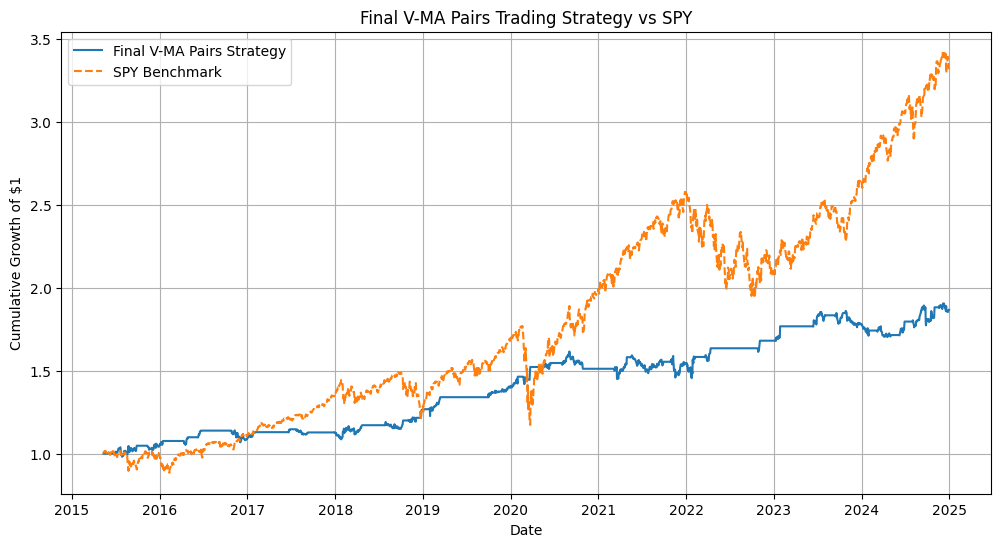

In [110]:
plt.figure(figsize=(12, 6))

plt.plot(
    final_cumulative_returns.index,
    final_cumulative_returns["Final V-MA Pairs Strategy"],
    label="Final V-MA Pairs Strategy"
)

plt.plot(
    final_cumulative_returns.index,
    final_cumulative_returns["SPY Benchmark"],
    label="SPY Benchmark",
    linestyle="--"
)

plt.title("Final V-MA Pairs Trading Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

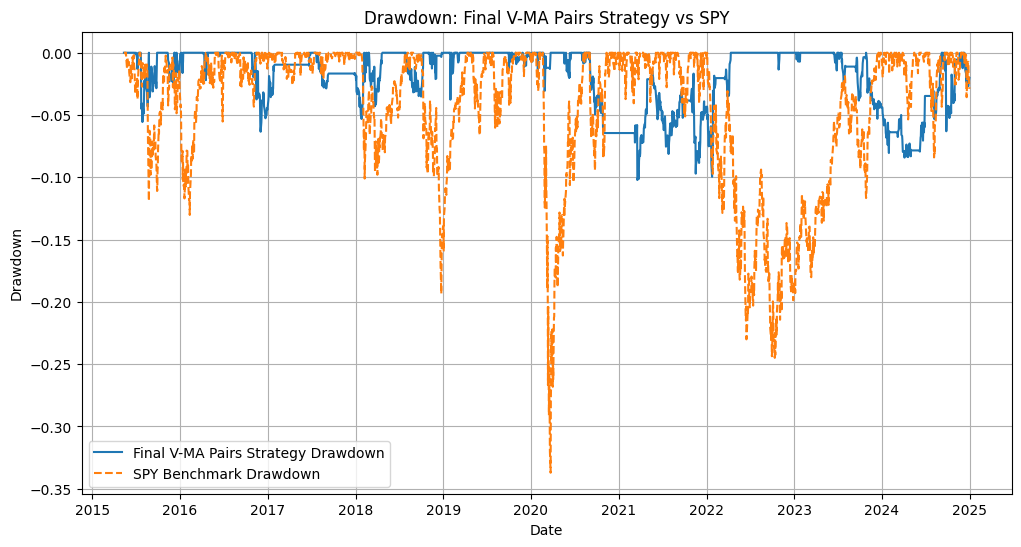

In [111]:
final_strategy_drawdown = (
    final_cumulative_strategy / final_cumulative_strategy.cummax()
) - 1

final_benchmark_drawdown = (
    final_cumulative_benchmark / final_cumulative_benchmark.cummax()
) - 1

plt.figure(figsize=(12, 6))

plt.plot(
    final_strategy_drawdown.index,
    final_strategy_drawdown,
    label="Final V-MA Pairs Strategy Drawdown"
)

plt.plot(
    final_benchmark_drawdown.index,
    final_benchmark_drawdown,
    label="SPY Benchmark Drawdown",
    linestyle="--"
)

plt.title("Drawdown: Final V-MA Pairs Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Final Strategy Selection

After testing different rolling windows and entry thresholds, the final strategy uses:

- Pair: Visa (V) and Mastercard (MA)
- Rolling window: 90 days
- Entry threshold: ±2.0
- Exit threshold: 0.0
- Transaction cost: 0.10% per position change

The final strategy achieved a total return of 86.75%, an annualized return of 6.71%, and a Sharpe ratio of 0.79. Its maximum drawdown was -10.22%, which was substantially lower than SPY's drawdown during the same period.

Although the strategy did not outperform SPY in total return, it produced a much smoother return profile with lower volatility and smaller drawdowns. This makes the strategy useful as an example of a lower-risk, relative-value approach rather than a pure market outperformance strategy.

## Final Results

The final V-MA pairs trading strategy used a 90-day rolling window, ±2.0 entry threshold, 0.0 exit threshold, and a 0.10% transaction cost per position change.

The final strategy achieved:

- Total Return: 86.75%
- Annualized Return: 6.71%
- Annualized Volatility: 8.44%
- Sharpe Ratio: 0.79
- Maximum Drawdown: -10.22%
- Win Rate: 23.96%
- Number of Entries: 35
- Number of Exits: 35

Over the same aligned period, SPY achieved a higher cumulative return. However, the pairs trading strategy had a much lower volatility and a substantially smaller maximum drawdown.

This suggests that the V-MA pairs strategy did not outperform SPY in terms of total return, but it offered a smoother and more defensive return profile.

## Limitations

This project has several important limitations:

1. Single Pair Focus  
   The final backtest focuses only on Visa and Mastercard. A more robust strategy would test and trade multiple cointegrated pairs.

2. Static Hedge Ratio  
   The hedge ratio is estimated once using the full historical period. In a real trading system, the hedge ratio should be estimated using a rolling or expanding window to avoid look-ahead bias.

3. Simplified Transaction Costs  
   A flat 0.10% transaction cost is applied per position change. Real trading would include bid-ask spreads, borrow costs, shorting costs, and slippage.

4. No Position Sizing Optimization  
   The strategy uses a simple spread return calculation and does not optimize capital allocation or risk exposure.

5. No Stop-Loss Rule  
   The strategy exits when the z-score reverts to zero, but it does not include stop-loss rules for cases where the spread continues to diverge.

6. Parameter Sensitivity  
   The strategy performance depends on the rolling window and entry threshold. Testing too many parameters may lead to overfitting.

7. SPY Is Not a Perfect Benchmark  
   SPY is a long-only market benchmark, while pairs trading is closer to a long-short relative-value strategy. Therefore, the comparison is useful but not perfectly equivalent.

## Next Steps

Possible improvements for this project include:

- Testing more candidate pairs across different sectors
- Using rolling hedge ratios instead of a static hedge ratio
- Building a multi-pair portfolio
- Adding stop-loss and take-profit rules
- Testing different exit thresholds
- Including borrow costs and more realistic slippage assumptions
- Evaluating performance by trade instead of only by daily returns
- Comparing the strategy against a market-neutral benchmark